
 BEAM SEARCH 

Level 0
 Current Beam : ['S']
 Candidates : ['A', 'B', 'C']
Sorted: [('B', 3), ('C', 5), ('A', 6)]
Selected: [('B', 3), ('C', 5)]
Discarded: [('A', 6)]

Level 1
 Current Beam : ['B', 'C']
 Candidates : ['F', 'G', 'H', 'I']
Sorted: [('F', 2), ('H', 3), ('G', 6), ('I', 8)]
Selected: [('F', 2), ('H', 3)]
Discarded: [('G', 6), ('I', 8)]

Level 2
 Current Beam : ['F', 'H']

Goal Found !
 Final Path : S -> B -> F


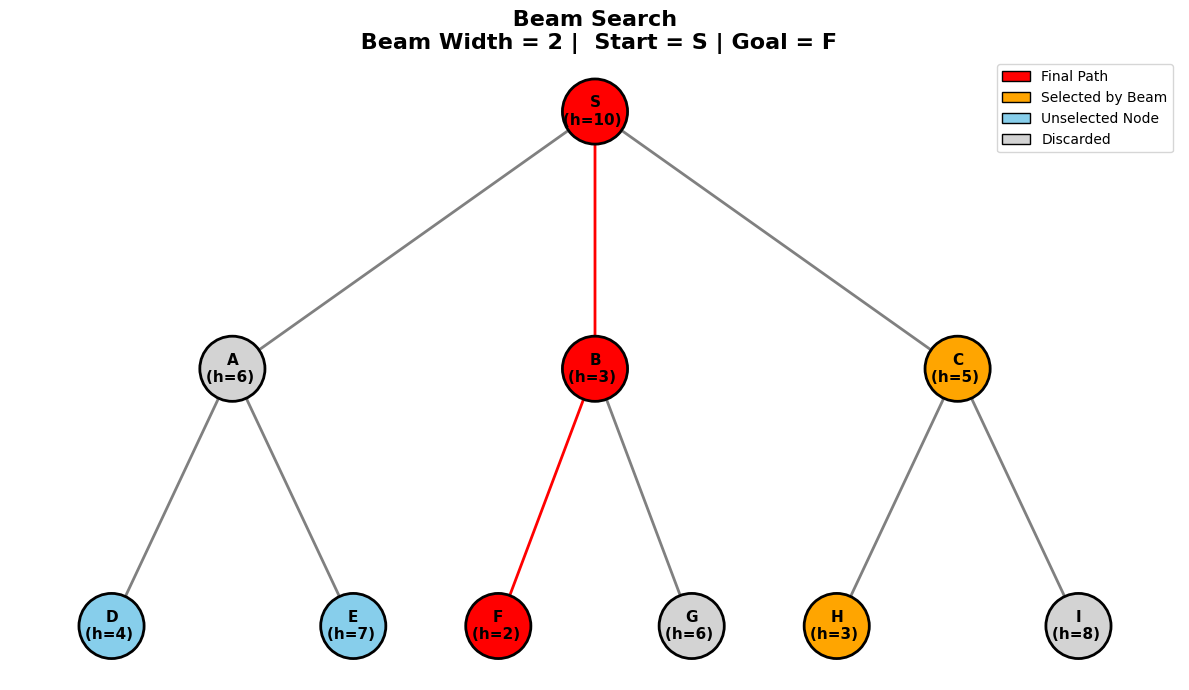

In [8]:
import networkx as nx
import matplotlib . pyplot as plt

def beam_search ( graph , heuristic , start , goal , beam_width ) :
   parent = { start : None }
   beam = [ start ]
   selected_nodes = { start }
   discarded_nodes = set ()
   expanded_nodes = set ()
   print ("\n ============================== ")
   print (" BEAM SEARCH ")
   print (" ============================== ")
   level = 0
   while beam :
    print ( f"\nLevel { level }")
    print (" Current Beam :", beam )

    if goal in beam :
      print ("\nGoal Found !")
      path = []
      current = goal
      while current is not None :
        path . append ( current )
        current = parent [ current ]
      path.reverse() # This was inside the while loop, causing issues
      print (" Final Path :", " -> ". join ( path ) )
      return (
          path ,
          selected_nodes ,
          discarded_nodes ,
          expanded_nodes
          )

    candidates = []
    for node in beam :
      expanded_nodes . add ( node )
      for neighbor in graph . get ( node , []) :
       if neighbor not in selected_nodes :
         candidates . append ( neighbor )
       if neighbor not in parent :
          parent [ neighbor ] = node

    candidates = list ( dict . fromkeys ( candidates ) )
    print (" Candidates :", candidates )

    candidates . sort ( key = lambda x : heuristic [ x ])
    print (
           "Sorted:",
       [( node , heuristic [ node ]) for node in candidates ]
          )
    new_beam = candidates [: beam_width ]
    discarded = candidates [ beam_width :]
    discarded_nodes . update ( discarded )
    selected_nodes . update ( new_beam )
    print (
        "Selected:",
         [( node , heuristic [ node ]) for node in new_beam ]
        )
    print (
        "Discarded:",
         [( node , heuristic [ node ]) for node in discarded ]
        )
    beam = new_beam
    level += 1

    if not beam and goal not in selected_nodes:
        print ("\nGoal could not be reached .")
        return (
            None,
            selected_nodes ,
            discarded_nodes ,
            expanded_nodes
            )

graph={
    'S':['A','B','C'],
    'A':['D','E'],
    'B':['F','G'],
    'C':['H','I'],

    'D':[],
    'E':[],
    'F':[],
    'G':[],
    'H':[],
    'I':[]
    }

heuristic={
    'S': 10,
    'A': 6,
    'B': 3,
    'C': 5,
    'D': 4,
    'E': 7,
    'F': 2,
    'G': 6,
    'H': 3,
    'I': 8
}
start='S'
goal='F'
beam_width=2
result = beam_search(
    graph,
    heuristic,
    start,
    goal,
    beam_width
)

# Ensure result is not None before unpacking
if result:
    path, selected_nodes, discarded_nodes, expanded_nodes = result
else:
    path = None # Handle case where goal is not reached
    selected_nodes = set()
    discarded_nodes = set()
    expanded_nodes = set()

G=nx.DiGraph() # Changed DiGrapg to DiGraph
for node in graph:
  G.add_node(node)
  for neighbor in graph[node]:
    G.add_edge(node, neighbor)

pos = {
    'S':(0,3),
    'A':(-3,2),
    'B':(0,2),
    'C':(3,2),
    'D':(-4,1),
    'E':(-2,1),
    'F':(-0.8,1),
    'G':(0.8,1),
    'H':(2,1),
    'I':(4,1)
}
node_colors = []
for node in G . nodes () :
  if path and node in path :
    node_colors . append ("red") # Removed trailing space
  elif node in discarded_nodes :
    node_colors . append ("lightgray") # Removed leading/trailing spaces
  elif node in selected_nodes :
    node_colors . append ("orange") # Removed trailing space
  else :
    node_colors . append ("skyblue") # Removed trailing space
edge_colors = [] # This line was incorrectly indented
for edge in G . edges () :
  u , v = edge
  if path and u in path and v in path :
    valid = False
    for i in range (len ( path ) - 1) :
      if path [ i ] == u and path [ i + 1] == v :
        valid = True
        break
    if valid :
      edge_colors . append ("red") # Removed trailing space
    else :
      edge_colors . append ("gray") # Removed trailing space
  else :
      edge_colors . append ("gray") # Removed trailing space

labels = {} # This line was incorrectly indented
for node in G . nodes () :
    labels [ node ] = f"{ node }\n(h={ heuristic [ node ]}) "

plt . figure ( figsize =(12 , 7) ) # This line was incorrectly indented
nx . draw_networkx_edges (
    G ,
    pos ,
    edge_color = edge_colors ,
    arrows = True ,
    arrowsize =20 ,
    width =2
    )
nx . draw_networkx_nodes (
    G ,
    pos ,
    node_color = node_colors ,
    node_size =2200 ,
    edgecolors ="black", # Removed trailing space
    linewidths =2
    )
nx . draw_networkx_labels (
    G ,
    pos ,
    labels = labels ,
    font_size =11 ,
    font_weight ="bold" # Removed trailing space
    )
plt . title ( # This line was incorrectly indented
    f" Beam Search \n"
    f" Beam Width = { beam_width } | "
    f" Start = { start } | Goal = { goal }",
    fontsize =16 ,
    fontweight ="bold" # Removed trailing space
    )
from matplotlib . patches import Patch # This line was incorrectly indented
legend_elements = [
    Patch (
        facecolor ="red", # Removed trailing space
        edgecolor ="black", # Removed trailing space
        label ="Final Path" # Removed trailing space
        ) ,
    Patch (
        facecolor ="orange", # Removed trailing space
        edgecolor ="black", # Removed trailing space
        label ="Selected by Beam" # Removed trailing space
        ) ,
    Patch (
        facecolor ="skyblue", # Removed trailing space
        edgecolor ="black", # Removed trailing space
        label ="Unselected Node" # Removed trailing space
        ),
    Patch (
        facecolor ="lightgray", # Removed trailing space
        edgecolor ="black", # Removed trailing space
        label ="Discarded" # Removed trailing space
        )
    ]
plt . legend (
    handles = legend_elements ,
    loc ="upper right" # Removed trailing space
    )
plt . axis ("off") # Removed trailing space
plt . tight_layout ()
plt . show ()